## Assignment 1: RNN for Time Series Forecasting -

Task: You are provided with a hypothetical time series dataset (e.g., daily stock prices, sensor readings, or weather data). Design an experiment to evaluate the effectiveness of an RNN model (e.g., LSTM or GRU) for forecasting future values in this series. Your design should include:

In [ ]:
# 1. Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

### Data Generation (Replace with your actual dataset loading and initial exploration)

For demonstration purposes, we'll generate a synthetic time series. In your actual assignment, you will load and explore your given dataset.

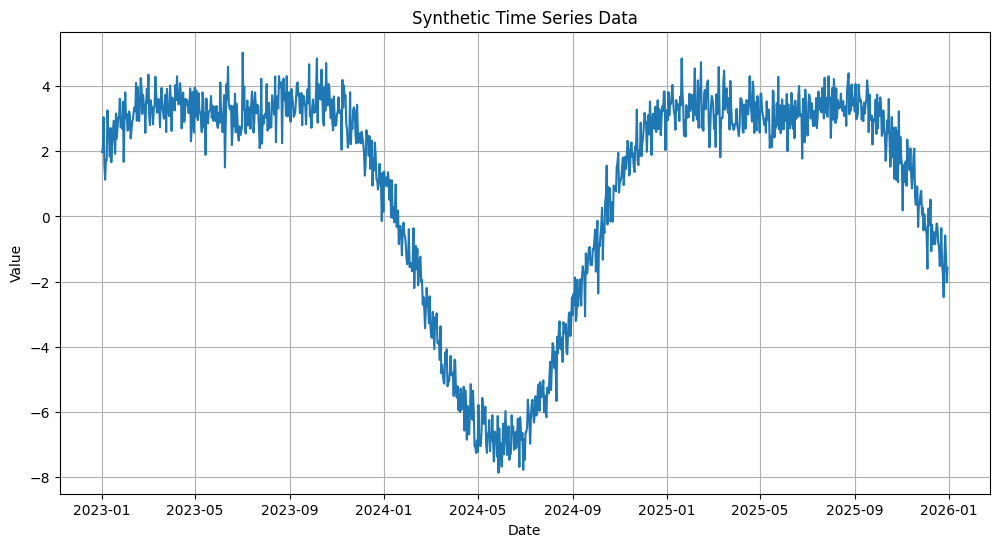

In [ ]:
# Generate synthetic time series data
def generate_time_series(num_points):
    time = np.linspace(0, 100, num_points)
    data = 5 * np.sin(time / 10) + 2 * np.cos(time / 5) + np.random.normal(0, 0.5, num_points)
    return pd.Series(data, index=pd.to_datetime(pd.date_range(start='2023-01-01', periods=num_points, freq='D')))

num_points = 365 * 3 # 3 years of daily data
time_series = generate_time_series(num_points)

plt.figure(figsize=(12, 6))
plt.plot(time_series)
plt.title('Synthetic Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

### Data Preprocessing

This involves scaling the data and creating sequences (windows) for the RNN model. You'll need to define `look_back` (number of previous time steps to consider) and `forecast_horizon` (number of future steps to predict).

In [ ]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(time_series.values.reshape(-1, 1))


In [ ]:

# Define look-back window and forecast horizon
look_back = 30 # Number of previous time steps to use as input
forecast_horizon = 1 # Number of future time steps to predict


In [ ]:

# Function to create dataset with look-back windows
def create_dataset(data, look_back=1, forecast_horizon=1):
    X, Y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        X.append(data[i:(i + look_back), 0])
        Y.append(data[i + look_back : i + look_back + forecast_horizon, 0])
    return np.array(X), np.array(Y)


In [ ]:

X, y = create_dataset(scaled_data, look_back, forecast_horizon)

# Reshape input to be [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (targets): {y.shape}")


Shape of X (features): (1065, 30, 1)
Shape of y (targets): (1065, 1)


In [ ]:

# Split data into training and testing sets
# Use a time-based split for time series data
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size,:], X[train_size:len(X),:]
y_train, y_test = y[0:train_size,:], y[train_size:len(y),:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (852, 30, 1), y_train shape: (852, 1)
X_test shape: (213, 30, 1), y_test shape: (213, 1)


### Model Configuration (Example LSTM Model)

This is a basic LSTM model. You should experiment with different architectures, layers, and hyperparameters.

In [ ]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(look_back, 1)))
model.add(Dense(forecast_horizon))
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

### Training and Evaluation Strategy

Train the model and then evaluate its performance on the test set. Remember to inverse transform the predictions to get actual values.

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=2, validation_split=0.2)


Epoch 1/50
22/22 - 2s - 101ms/step - loss: 0.4035 - val_loss: 0.3630
Epoch 2/50
22/22 - 1s - 48ms/step - loss: 0.0799 - val_loss: 0.0052
Epoch 3/50
22/22 - 1s - 30ms/step - loss: 0.0099 - val_loss: 0.0023
Epoch 4/50
22/22 - 1s - 25ms/step - loss: 0.0043 - val_loss: 0.0020
Epoch 5/50
22/22 - 1s - 29ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 6/50
22/22 - 1s - 29ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 7/50
22/22 - 0s - 18ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 8/50
22/22 - 0s - 16ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 9/50
22/22 - 1s - 28ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 10/50
22/22 - 0s - 16ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 11/50
22/22 - 0s - 17ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 12/50
22/22 - 0s - 16ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 13/50
22/22 - 0s - 16ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 14/50
22/22 - 0s - 17ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 15/50
22/22 - 1s - 28ms/step - loss:

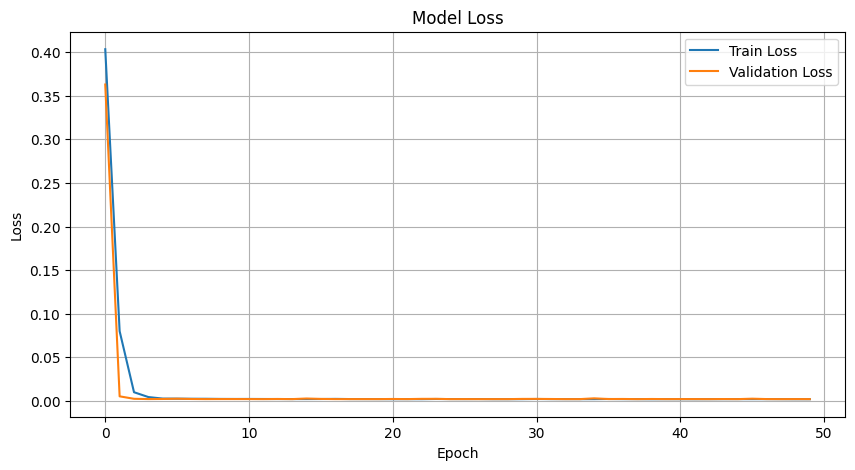

In [ ]:

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:

# Inverse transform predictions and actual values
y_train_pred_inv = scaler.inverse_transform(y_train_pred)
y_train_inv = scaler.inverse_transform(y_train)
y_test_pred_inv = scaler.inverse_transform(y_test_pred)
y_test_inv = scaler.inverse_transform(y_test)


Train RMSE: 0.552, MAE: 0.438
Test RMSE: 0.566, MAE: 0.456


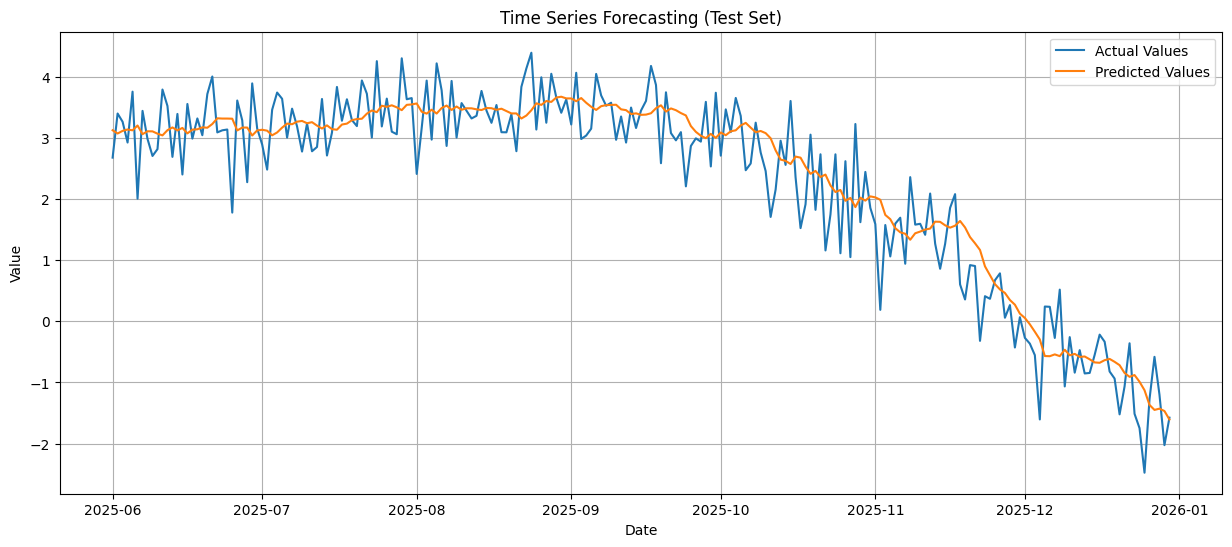

In [ ]:

# Calculate evaluation metrics
rmse_train = np.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
mae_train = mean_absolute_error(y_train_inv, y_train_pred_inv)

rmse_test = np.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
mae_test = mean_absolute_error(y_test_inv, y_test_pred_inv)

print(f'Train RMSE: {rmse_train:.3f}, MAE: {mae_train:.3f}')
print(f'Test RMSE: {rmse_test:.3f}, MAE: {mae_test:.3f}')

# Plot actual vs. predicted (for a segment of the test data)
plt.figure(figsize=(15, 6))
plt.plot(time_series.index[-len(y_test_inv):], y_test_inv, label='Actual Values')
plt.plot(time_series.index[-len(y_test_pred_inv):], y_test_pred_inv, label='Predicted Values')
plt.title('Time Series Forecasting (Test Set)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Error Analysis Considerations

After running this starter code, critically analyze the results. If the model performance is not satisfactory, consider the following points for your error analysis as outlined in Assignment 2:

*   **Hypothesis 1: Insufficient Feature Engineering/Preprocessing.**
    *   **Test:** Experiment with different `look_back` windows, feature scaling methods (e.g., standard scaler), or adding external features if available (e.g., day of week, holidays, trends).
*   **Hypothesis 2: Model Complexity Mismatch.**
    *   **Test:** Try increasing or decreasing the number of LSTM units, adding more LSTM layers, or exploring other RNN types like GRU. Also, check for overfitting/underfitting by monitoring train vs. validation loss.
*   **Hypothesis 3: Suboptimal Hyperparameters.**
    *   **Test:** Experiment with different learning rates for the optimizer, batch sizes, and a larger number of epochs. Consider using techniques like early stopping.
*   **Hypothesis 4: Data Quality Issues.**
    *   **Test:** Re-examine the raw data for anomalies, missing values, or significant outliers that were not properly handled during initial preprocessing.

#Assignment 2

Build LSTM model for Patient Monitoring: Analyzing real-time, time-series data like heart rate, ECG, and blood pressure to predict critical events.dataset provided patient_monitoring.csv

### Loading and Initial Exploration of Patient Monitoring Data

In [ ]:
# Load the patient monitoring dataset
patient_df = pd.read_csv('patient_monitoring.csv')

# Display the first 5 rows of the dataset
display(patient_df.head())

# Get information about the dataset, including data types and non-null values
print(patient_df.info())

,Unnamed: 0,heart_rate,sys_bp,dia_bp,ecg,event
0,0,101.0,124.0,79.0,-0.9539,1
1,1,100.0,123.0,80.0,-0.4302,0
2,2,102.0,120.0,78.0,-0.2068,0
3,3,104.0,118.0,79.0,0.9438,0
4,4,100.0,122.0,76.0,0.2783,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   heart_rate  1000 non-null   float64
 2   sys_bp      1000 non-null   float64
 3   dia_bp      1000 non-null   float64
 4   ecg         1000 non-null   float64
 5   event       1000 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 47.0 KB
None


### Data Preprocessing for Patient Monitoring Data

In [ ]:
# Rename 'Unnamed: 0' to 'Time' as it appears to be the time-step identifier
patient_df = patient_df.rename(columns={'Unnamed: 0': 'Time'})

# Identify time column and feature columns
time_column = 'Time'
feature_columns = ['heart_rate', 'sys_bp', 'dia_bp', 'ecg'] # Corrected feature column names

# Convert 'Time' column to datetime objects. Assuming unit is 'D' (days) from an arbitrary origin.
# If specific date information is available, a different conversion might be needed.
patient_df[time_column] = pd.to_datetime(patient_df[time_column], unit='D', origin='2023-01-01')

# Set 'Time' as the index for time-series analysis
patient_df = patient_df.set_index(time_column)

# Sort the DataFrame by index (time) to ensure chronological order
patient_df = patient_df.sort_index()

# Display basic information about the processed DataFrame
print("\nDataFrame after setting Time as index and sorting:")
print(patient_df.info())

# Check for missing values
print("\nMissing values per column:")
print(patient_df.isnull().sum())

# Check for duplicate timestamps (if 'Time' was not set as index)
print("\nNumber of duplicate timestamps:", patient_df.index.duplicated().sum())


DataFrame after setting Time as index and sorting:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1000 entries, 2023-01-01 to 2025-09-26
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   heart_rate  1000 non-null   float64
 1   sys_bp      1000 non-null   float64
 2   dia_bp      1000 non-null   float64
 3   ecg         1000 non-null   float64
 4   event       1000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 46.9 KB
None

Missing values per column:
heart_rate    0
sys_bp        0
dia_bp        0
ecg           0
event         0
dtype: int64

Number of duplicate timestamps: 0


#### Define Critical Events (Target Variable)

For patient monitoring, a 'critical event' needs to be defined. This could be based on specific thresholds for physiological parameters (e.g., heart rate too high/low, blood pressure abnormal). For demonstration, let's assume a critical event occurs if:
- Heart Rate is below 60 BPM (Bradycardia) or above 100 BPM (Tachycardia)
- Blood Pressure (systolic) is below 90 mmHg (Hypotension) or above 140 mmHg (Hypertension)

We will create a new target column `CriticalEvent` which will be 1 if any of these conditions are met, and 0 otherwise.

In [ ]:
# Define thresholds for critical events
heart_rate_low_threshold = 60
heart_rate_high_threshold = 100
blood_pressure_low_threshold = 90
blood_pressure_high_threshold = 140

# Create the 'CriticalEvent' column using corrected column names
patient_df['CriticalEvent'] = (
    (patient_df['heart_rate'] < heart_rate_low_threshold) |
    (patient_df['heart_rate'] > heart_rate_high_threshold) |
    (patient_df['sys_bp'] < blood_pressure_low_threshold) | # Assuming sys_bp for high/low blood pressure
    (patient_df['sys_bp'] > blood_pressure_high_threshold)  # Assuming sys_bp for high/low blood pressure
).astype(int)

print("\nDistribution of Critical Events:")
print(patient_df['CriticalEvent'].value_counts())

# Display the DataFrame with the new 'CriticalEvent' column
display(patient_df.head())


Distribution of Critical Events:
CriticalEvent
1    516
0    484
Name: count, dtype: int64


,heart_rate,sys_bp,dia_bp,ecg,event,CriticalEvent
Time,,,,,,
2023-01-01,101.0,124.0,79.0,-0.9539,1,1
2023-01-02,100.0,123.0,80.0,-0.4302,0,0
2023-01-03,102.0,120.0,78.0,-0.2068,0,1
2023-01-04,104.0,118.0,79.0,0.9438,0,1
2023-01-05,100.0,122.0,76.0,0.2783,0,0


#### Scaling Numerical Features

We will scale the numerical features (`HeartRate`, `ECG`, `BloodPressure`) using `MinMaxScaler` to normalize them between 0 and 1. This is crucial for LSTM models as they are sensitive to the scale of input data.

In [ ]:
# Initialize MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Scale the feature columns
patient_df[feature_columns] = scaler.fit_transform(patient_df[feature_columns])

# Display the scaled data
print("\nDataFrame after scaling features:")
display(patient_df.head())


DataFrame after scaling features:


,heart_rate,sys_bp,dia_bp,ecg,event,CriticalEvent
Time,,,,,,
2023-01-01,0.551724,0.606061,0.3750,0.165511,1,1
2023-01-02,0.517241,0.575758,0.4375,0.335202,0,0
2023-01-03,0.586207,0.484848,0.3125,0.407589,0,1
2023-01-04,0.655172,0.424242,0.3750,0.780410,0,1
2023-01-05,0.517241,0.545455,0.1875,0.564772,0,0


#Assignment 3


Use LSTM for Fraud Detection: Identifying unusual patterns in financial transactions..dataset provided complex_fraud_dataset.csv


### Loading and Initial Exploration of Complex Fraud Dataset

In [ ]:
# Load the complex fraud dataset
fraud_df = pd.read_csv('complex_fraud_dataset.csv')

# Display the first 5 rows of the dataset
display(fraud_df.head())

# Get information about the dataset, including data types and non-null values
print(fraud_df.info())

,amount,balance,hour,day,time_since_last,distance,speed,merchant_risk,cardholder_risk,device,ip_risk,z_score,is_fraud
0,70,4862,18,4,1200.44,11,29,0.07,0.03,1,0.07,-0.46,0
1,62,4840,13,1,1347.32,4,32,0.09,0.06,1,0.06,-0.96,0
2,51,4258,10,3,1951.90,6,31,0.03,0.01,1,0.09,-0.26,0
3,48,4708,11,3,1235.69,5,25,0.18,0.05,1,0.07,0.00,0
4,64,3040,17,3,1483.73,8,20,0.05,0.17,1,0.04,-0.79,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   amount           5000 non-null   int64  
 1   balance          5000 non-null   int64  
 2   hour             5000 non-null   int64  
 3   day              5000 non-null   int64  
 4   time_since_last  5000 non-null   float64
 5   distance         5000 non-null   int64  
 6   speed            5000 non-null   int64  
 7   merchant_risk    5000 non-null   float64
 8   cardholder_risk  5000 non-null   float64
 9   device           5000 non-null   int64  
 10  ip_risk          5000 non-null   float64
 11  z_score          5000 non-null   float64
 12  is_fraud         5000 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 507.9 KB
None


### Data Preprocessing for Fraud Detection

In [ ]:
# Identify feature columns and the target variable
# We will use all columns except 'is_fraud' as features for now
feature_columns_fraud = [col for col in fraud_df.columns if col != 'is_fraud']
target_column_fraud = 'is_fraud'

# Separate features (X) and target (y)
X_fraud = fraud_df[feature_columns_fraud]
y_fraud = fraud_df[target_column_fraud]

# Display basic information about the processed DataFrame
print("\nDataFrame info after separating features and target:")
print(X_fraud.info())

# Check for missing values
print("\nMissing values per column in features:")
print(X_fraud.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", fraud_df.duplicated().sum())


DataFrame info after separating features and target:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   amount           5000 non-null   int64  
 1   balance          5000 non-null   int64  
 2   hour             5000 non-null   int64  
 3   day              5000 non-null   int64  
 4   time_since_last  5000 non-null   float64
 5   distance         5000 non-null   int64  
 6   speed            5000 non-null   int64  
 7   merchant_risk    5000 non-null   float64
 8   cardholder_risk  5000 non-null   float64
 9   device           5000 non-null   int64  
 10  ip_risk          5000 non-null   float64
 11  z_score          5000 non-null   float64
dtypes: float64(5), int64(7)
memory usage: 468.9 KB
None

Missing values per column in features:
amount             0
balance            0
hour               0
day                0
time_since_las

#### Scaling Numerical Features

Scale the numerical features using `MinMaxScaler` to normalize them between 0 and 1. This is important for LSTM models.

In [ ]:
# Initialize MinMaxScaler
scaler_fraud = MinMaxScaler(feature_range=(0, 1))

# Scale the feature columns
X_scaled_fraud = scaler_fraud.fit_transform(X_fraud)

# Convert back to DataFrame for easier handling, retaining column names
X_scaled_fraud_df = pd.DataFrame(X_scaled_fraud, columns=feature_columns_fraud)

# Display the scaled data
print("\nDataFrame after scaling features:")
display(X_scaled_fraud_df.head())


DataFrame after scaling features:


,amount,balance,hour,day,time_since_last,distance,speed,merchant_risk,cardholder_risk,device,ip_risk,z_score
0,0.018582,0.446361,0.90,1.00,0.566190,0.009744,0.058015,0.07,0.15,1.0,0.07,0.183857
1,0.016747,0.443373,0.65,0.25,0.635524,0.005481,0.062595,0.09,0.30,1.0,0.06,0.109118
2,0.014223,0.364340,0.50,0.75,0.920914,0.006699,0.061069,0.03,0.05,1.0,0.09,0.213752
3,0.013535,0.425448,0.55,0.75,0.582830,0.006090,0.051908,0.18,0.25,1.0,0.07,0.252616
4,0.017206,0.198941,0.85,0.75,0.699916,0.007917,0.044275,0.05,0.85,1.0,0.04,0.134529


#### Creating Sequences for LSTM

For fraud detection, we'll create sequences similar to time series forecasting. Each sequence will represent a series of transactions (e.g., the last `look_back` transactions) to predict whether the _next_ transaction (`forecast_horizon` = 1) is fraudulent. Note: The dataset provided for fraud detection is typically not ordered by time in a continuous stream for each user, but rather individual transactions. For simplicity, we'll treat each row as a 'time step' in a generic sequence for the purpose of demonstrating LSTM application. In a real-world scenario, you would group transactions by user and build sequences per user.

Here, `look_back` will represent the number of previous transactions considered to predict the fraud status of the current transaction. Since this is not a true time series of a single entity, the `look_back` window slides over the dataset as if it were a continuous stream.

In [ ]:
# Define look-back window and forecast horizon
look_back_fraud = 10 # Number of previous transactions to consider
forecast_horizon_fraud = 1 # Predict if the current transaction is fraud

# Function to create dataset with look-back windows for fraud detection
# X_fraud will be sequences of features, y_fraud will be the 'is_fraud' for the last transaction in the sequence
def create_sequences_fraud(features, target, look_back):
    X, y = [], []
    for i in range(len(features) - look_back):
        X.append(features[i:(i + look_back)])
        y.append(target.iloc[i + look_back]) # Target for the transaction at the end of the sequence
    return np.array(X), np.array(y)

# Convert scaled features to numpy array for sequence creation
X_scaled_np_fraud = X_scaled_fraud_df.values

# Create sequences
X_seq_fraud, y_seq_fraud = create_sequences_fraud(X_scaled_np_fraud, y_fraud, look_back_fraud)

print(f"Shape of X_seq_fraud (features): {X_seq_fraud.shape}")
print(f"Shape of y_seq_fraud (targets): {y_seq_fraud.shape}")

Shape of X_seq_fraud (features): (4990, 10, 12)
Shape of y_seq_fraud (targets): (4990,)


#### Splitting Data into Training and Testing Sets

For fraud detection, it's common to split the data randomly, but for time-series-like problems with LSTM, a chronological split might also be considered if the order truly matters. Given this dataset structure, a simple train-test split is sufficient for demonstration.

In [ ]:
# Split data into training and testing sets
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_seq_fraud, y_seq_fraud, test_size=0.2, random_state=42, stratify=y_seq_fraud # Stratify to maintain fraud ratio
)

print(f"X_train_fraud shape: {X_train_fraud.shape}, y_train_fraud shape: {y_train_fraud.shape}")
print(f"X_test_fraud shape: {X_test_fraud.shape}, y_test_fraud shape: {y_test_fraud.shape}")

# Check distribution of fraud in train and test sets
print("\nTraining target distribution:")
print(pd.Series(y_train_fraud).value_counts(normalize=True))
print("\nTesting target distribution:")
print(pd.Series(y_test_fraud).value_counts(normalize=True))

X_train_fraud shape: (3992, 10, 12), y_train_fraud shape: (3992,)
X_test_fraud shape: (998, 10, 12), y_test_fraud shape: (998,)

Training target distribution:
1    0.501002
0    0.498998
Name: proportion, dtype: float64

Testing target distribution:
1    0.501002
0    0.498998
Name: proportion, dtype: float64


#Assignment 4

Use LSTM for Sentiment Analysis: Determining if a piece of text (e.g., product review) expresses positive, negative, or neutral sentiment.dataset link https://www.kaggle.com/datasets/saurav9786/amazon-product-reviews


In [ ]:
# Add necessary imports for text preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Load the sentiment analysis dataset, explicitly defining column names
# Based on the previous output, the file likely has no header and contains: item_id, user_id, rating, timestamp.
sentiment_df = pd.read_csv('ratings_Electronics (1).csv', header=None,
                          names=['item_id', 'user_id', 'rating', 'timestamp'])

# Display the first 5 rows of the dataset
display(sentiment_df.head())

# Get information about the dataset, including data types and non-null values
print(sentiment_df.info())

,item_id,user_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   item_id    object 
 1   user_id    object 
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB
None


#### Inferring Sentiment from Ratings

Since `reviewText` is not available, we will infer sentiment directly from the `rating` column. A common approach is to categorize ratings into:
- **Positive:** Ratings >= 4
- **Neutral:** Rating = 3
- **Negative:** Ratings < 3

This will create our target variable for sentiment analysis.

In [ ]:
# Define a function to categorize ratings into sentiment
def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

# Apply the function to create the 'sentiment' column
sentiment_df['sentiment'] = sentiment_df['rating'].apply(get_sentiment)

# Display the distribution of the new sentiment column
print("\nSentiment Distribution:")
print(sentiment_df['sentiment'].value_counts())

# Display the first few rows with the new sentiment column
display(sentiment_df.head())


Sentiment Distribution:
sentiment
Positive    4594210
Negative    1086487
Neutral      496798
Name: count, dtype: int64


,item_id,user_id,rating,timestamp,sentiment
0,AKM1MP6P0OYPR,0132793040,5.0,1.365811e+09,Positive
1,A2CX7LUOHB2NDG,0321732944,5.0,1.341101e+09,Positive
2,A2NWSAGRHCP8N5,0439886341,1.0,1.367194e+09,Negative
3,A2WNBOD3WNDNKT,0439886341,3.0,1.374451e+09,Neutral
4,A1GI0U4ZRJA8WN,0439886341,1.0,1.334707e+09,Negative


#Assignment 5

Use LSTM to analyze past sales data, holidays, and promotions to predict future inventory needs. Unlike simple averages, they can pick up on complex seasonality (e.g., "sales spike every third Thursday").retail_demand_data,csv


### Loading and Initial Exploration of Retail Demand Data

In [ ]:
# Load the retail demand dataset
retail_df = pd.read_csv('retail_demand_data.csv')

# Display the first 5 rows of the dataset
display(retail_df.head())

# Get information about the dataset, including data types and non-null values
print(retail_df.info())

,date,day_of_week,is_weekend,is_third_thursday,on_promotion,units_sold,is_holiday
0,2023-01-01,6,1,0,0,548,0
1,2023-01-02,0,0,0,1,483,0
2,2023-01-03,1,0,0,0,519,0
3,2023-01-04,2,0,0,0,530,0
4,2023-01-05,3,0,0,0,527,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               1000 non-null   object
 1   day_of_week        1000 non-null   int64 
 2   is_weekend         1000 non-null   int64 
 3   is_third_thursday  1000 non-null   int64 
 4   on_promotion       1000 non-null   int64 
 5   units_sold         1000 non-null   int64 
 6   is_holiday         1000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 54.8+ KB
None


### Data Preprocessing for Retail Demand Data

To prepare the retail demand data for LSTM modeling, we need to:
1.  **Convert 'date' to datetime and set as index:** This ensures proper time-series handling.
2.  **Sort by date:** Critical for maintaining chronological order.
3.  **Identify features and target:** Define which columns will be used as input for the LSTM and which will be the target variable (`units_sold`).
4.  **Handle missing values (if any):** Though `retail_df.info()` showed no missing values, this is a general step to consider.

In [ ]:
# Assuming 'date' column has already been converted to datetime and set as index
# and the DataFrame is already sorted by date. We will proceed with identifying features and targets.

# Sort the DataFrame by index (date) to ensure chronological order (harmless if already sorted)
retail_df = retail_df.sort_index()

# Identify feature columns (all except 'units_sold') and the target variable
feature_columns_retail = [col for col in retail_df.columns if col != 'units_sold']
target_column_retail = 'units_sold'

# Display basic information about the processed DataFrame
print("\nDataFrame after setting 'date' as index and sorting:")
print(retail_df.info())

# Check for missing values
print("\nMissing values per column:")
print(retail_df.isnull().sum())

# Display the first few rows of the processed DataFrame
display(retail_df.head())


DataFrame after setting 'date' as index and sorting:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1000 entries, 2023-01-01 to 2025-09-26
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   day_of_week        1000 non-null   int64
 1   is_weekend         1000 non-null   int64
 2   is_third_thursday  1000 non-null   int64
 3   on_promotion       1000 non-null   int64
 4   units_sold         1000 non-null   int64
 5   is_holiday         1000 non-null   int64
dtypes: int64(6)
memory usage: 54.7 KB
None

Missing values per column:
day_of_week          0
is_weekend           0
is_third_thursday    0
on_promotion         0
units_sold           0
is_holiday           0
dtype: int64


,day_of_week,is_weekend,is_third_thursday,on_promotion,units_sold,is_holiday
date,,,,,,
2023-01-01,6,1,0,0,548,0
2023-01-02,0,0,0,1,483,0
2023-01-03,1,0,0,0,519,0
2023-01-04,2,0,0,0,530,0
2023-01-05,3,0,0,0,527,0


#### Scaling Numerical Features for Retail Demand Data

Scale all numerical features, including the target variable `units_sold`, using `MinMaxScaler`. This will normalize the data between 0 and 1, which is important for LSTM models.

In [ ]:
# Initialize MinMaxScaler for retail demand data
scaler_retail = MinMaxScaler(feature_range=(0, 1))

# Combine features and target for scaling to maintain their relative scales if needed,
# or scale features and target separately if they are to be handled differently later.
# For simplicity and typical time series forecasting, we'll scale everything together for now.
scaled_data_retail = scaler_retail.fit_transform(retail_df[feature_columns_retail + [target_column_retail]])

# Convert back to DataFrame for easier handling
scaled_retail_df = pd.DataFrame(scaled_data_retail, columns=feature_columns_retail + [target_column_retail], index=retail_df.index)

# Display the scaled data
print("\nDataFrame after scaling all relevant features and target:")
display(scaled_retail_df.head())
print(f"Scaled data shape: {scaled_data_retail.shape}")


DataFrame after scaling all relevant features and target:


,day_of_week,is_weekend,is_third_thursday,on_promotion,is_holiday,units_sold
date,,,,,,
2023-01-01,1.000000,1.0,0.0,0.0,0.0,0.514745
2023-01-02,0.000000,0.0,0.0,1.0,0.0,0.340483
2023-01-03,0.166667,0.0,0.0,0.0,0.0,0.436997
2023-01-04,0.333333,0.0,0.0,0.0,0.0,0.466488
2023-01-05,0.500000,0.0,0.0,0.0,0.0,0.458445


Scaled data shape: (1000, 6)


#### Creating Sequences for Retail Demand Data

For LSTM models, input data needs to be structured into sequences. We'll define:
-   `look_back_retail`: The number of previous time steps (days) to use as input features.
-   `forecast_horizon_retail`: The number of future time steps (days) to predict.

Then, we'll create a function to transform our scaled time series data into `X` (sequences of features) and `y` (corresponding target values).

In [ ]:
# Define look-back window and forecast horizon for retail demand
look_back_retail = 30  # Number of previous days to use as input
forecast_horizon_retail = 7 # Number of future days (e.g., a week) to predict

# Function to create dataset with look-back windows
def create_sequences_retail(data, look_back, forecast_horizon, features_count, target_idx):
    X, Y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        # Features (X) are the 'look_back' previous time steps across all features
        X.append(data[i:(i + look_back), :features_count])
        # Target (Y) is the 'forecast_horizon' future values of the target variable
        Y.append(data[i + look_back : i + look_back + forecast_horizon, target_idx])
    return np.array(X), np.array(Y)

# Get the index of the target column ('units_sold') within the scaled data
target_idx_retail = scaled_retail_df.columns.get_loc(target_column_retail)
features_count_retail = len(feature_columns_retail) + 1 # +1 for the target if it's included in X for scaling

# Create sequences for retail demand data
X_retail, y_retail = create_sequences_retail(
    scaled_retail_df.values, look_back_retail, forecast_horizon_retail, features_count_retail, target_idx_retail
)

print(f"Shape of X_retail (features): {X_retail.shape}")
print(f"Shape of y_retail (targets): {y_retail.shape}")

Shape of X_retail (features): (964, 30, 6)
Shape of y_retail (targets): (964, 7)


#### Splitting Retail Demand Data into Training and Testing Sets

For time series forecasting, it's essential to perform a time-based split rather than a random split. This ensures that the model is trained on historical data and tested on future, unseen data, preventing data leakage.

In [ ]:
# Split data into training and testing sets (time-based split)
train_size_retail = int(len(X_retail) * 0.8)

X_train_retail, X_test_retail = X_retail[0:train_size_retail,:], X_retail[train_size_retail:len(X_retail),:]
y_train_retail, y_test_retail = y_retail[0:train_size_retail,:], y_retail[train_size_retail:len(y_retail),:]

print(f"X_train_retail shape: {X_train_retail.shape}, y_train_retail shape: {y_train_retail.shape}")
print(f"X_test_retail shape: {X_test_retail.shape}, y_test_retail shape: {y_test_retail.shape}")

X_train_retail shape: (771, 30, 6), y_train_retail shape: (771, 7)
X_test_retail shape: (193, 30, 6), y_test_retail shape: (193, 7)


### Building the LSTM Model for Retail Demand Forecasting

Now we will define the LSTM model architecture for predicting future inventory needs. The model will take the `look_back_retail` (30 days) sequence of features and predict the `forecast_horizon_retail` (7 days) of `units_sold`.

We will use a `Sequential` model with one `LSTM` layer and a `Dense` output layer. The `input_shape` for the LSTM layer will be `(look_back_retail, X_retail.shape[2])`, where `X_retail.shape[2]` is the number of features per time step. The `Dense` layer will have `forecast_horizon_retail` units to match the 7-day prediction horizon.

In [ ]:
# Build the LSTM model for retail demand forecasting
model_retail = Sequential()
model_retail.add(LSTM(50, activation='relu', input_shape=(look_back_retail, X_retail.shape[2])))
model_retail.add(Dense(forecast_horizon_retail))
model_retail.compile(optimizer='adam', loss='mean_squared_error')

model_retail.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        11,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,757 (45.93 KB)

 Trainable params: 11,757 (45.93 KB)

 Non-trainable params: 0 (0.00 B)

### Training the LSTM Model for Retail Demand Forecasting

Now we will train the `model_retail` using the `X_train_retail` and `y_train_retail` datasets. We'll monitor the loss during training to see how well the model learns.


In [ ]:
# Train the retail demand forecasting model
history_retail = model_retail.fit(X_train_retail, y_train_retail, epochs=50, batch_size=32, verbose=2, validation_split=0.2)

Epoch 1/50
20/20 - 2s - 109ms/step - loss: 0.1275 - val_loss: 0.0432
Epoch 2/50
20/20 - 0s - 16ms/step - loss: 0.0327 - val_loss: 0.0282
Epoch 3/50
20/20 - 0s - 17ms/step - loss: 0.0262 - val_loss: 0.0276
Epoch 4/50
20/20 - 0s - 16ms/step - loss: 0.0252 - val_loss: 0.0269
Epoch 5/50
20/20 - 0s - 24ms/step - loss: 0.0247 - val_loss: 0.0265
Epoch 6/50
20/20 - 1s - 28ms/step - loss: 0.0242 - val_loss: 0.0262
Epoch 7/50
20/20 - 1s - 30ms/step - loss: 0.0239 - val_loss: 0.0258
Epoch 8/50
20/20 - 1s - 30ms/step - loss: 0.0237 - val_loss: 0.0260
Epoch 9/50
20/20 - 1s - 33ms/step - loss: 0.0235 - val_loss: 0.0254
Epoch 10/50
20/20 - 1s - 27ms/step - loss: 0.0234 - val_loss: 0.0254
Epoch 11/50
20/20 - 0s - 17ms/step - loss: 0.0232 - val_loss: 0.0250
Epoch 12/50
20/20 - 0s - 17ms/step - loss: 0.0231 - val_loss: 0.0251
Epoch 13/50
20/20 - 0s - 16ms/step - loss: 0.0231 - val_loss: 0.0248
Epoch 14/50
20/20 - 0s - 18ms/step - loss: 0.0230 - val_loss: 0.0251
Epoch 15/50
20/20 - 0s - 17ms/step - loss:

### Plotting Training History for Retail Demand Forecasting

We will plot the training loss and validation loss over the epochs to visualize the learning curve of the `model_retail`. This helps in understanding if the model is overfitting or underfitting.

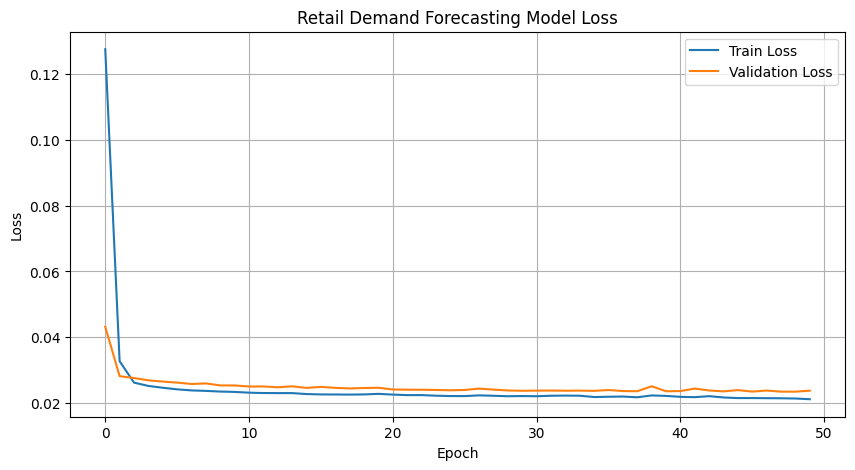

In [ ]:
# Plot training history for retail demand forecasting
plt.figure(figsize=(10, 5))
plt.plot(history_retail.history['loss'], label='Train Loss')
plt.plot(history_retail.history['val_loss'], label='Validation Loss')
plt.title('Retail Demand Forecasting Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Making Predictions and Inverse Transforming for Retail Demand Forecasting

We will now use the trained `model_retail` to make predictions on both the training and testing datasets. Since our data was scaled, we need to inverse transform both the predictions and the actual target values back to their original scale to facilitate meaningful evaluation and comparison.

In [ ]:
# Make predictions for retail demand forecasting
y_train_pred_retail = model_retail.predict(X_train_retail)
y_test_pred_retail = model_retail.predict(X_test_retail)

# Inverse transform predictions and actual values
# We need to reshape the arrays to fit the scaler's expected input (2D array)
# The scaler was fitted on a combined array of features + target, so we need to create dummy features to inverse transform only the target.

# Helper function for inverse transformation of multi-step forecasts
def inverse_transform_forecasts(scaled_values, scaler, target_idx, features_count, forecast_horizon):
    inverted_values = np.zeros_like(scaled_values)
    for k in range(forecast_horizon):
        # Create a temporary array for the current forecast step for all samples
        temp_array = np.zeros((scaled_values.shape[0], features_count))
        temp_array[:, target_idx] = scaled_values[:, k]
        # Inverse transform and extract the target column
        inverted_values[:, k] = scaler.inverse_transform(temp_array)[:, target_idx]
    return inverted_values

# Apply inverse transformation for all sets
y_train_pred_inv_retail = inverse_transform_forecasts(y_train_pred_retail, scaler_retail, target_idx_retail, features_count_retail, forecast_horizon_retail)
y_train_inv_retail = inverse_transform_forecasts(y_train_retail, scaler_retail, target_idx_retail, features_count_retail, forecast_horizon_retail)
y_test_pred_inv_retail = inverse_transform_forecasts(y_test_pred_retail, scaler_retail, target_idx_retail, features_count_retail, forecast_horizon_retail)
y_test_inv_retail = inverse_transform_forecasts(y_test_retail, scaler_retail, target_idx_retail, features_count_retail, forecast_horizon_retail)

print(f"y_train_pred_inv_retail shape: {y_train_pred_inv_retail.shape}")
print(f"y_train_inv_retail shape: {y_train_inv_retail.shape}")
print(f"y_test_pred_inv_retail shape: {y_test_pred_inv_retail.shape}")
print(f"y_test_inv_retail shape: {y_test_inv_retail.shape}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
y_train_pred_inv_retail shape: (771, 7)
y_train_inv_retail shape: (771, 7)
y_test_pred_inv_retail shape: (193, 7)
y_test_inv_retail shape: (193, 7)


### Evaluating Retail Demand Forecasting Model

Now, we will evaluate the performance of our retail demand forecasting model using common regression metrics such as Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE). These metrics will be calculated for both the training and testing sets to assess how well the model is learning and generalizing.

After calculating the metrics, we will visualize the inverse-transformed actual and predicted `units_sold` values for the test set. This visual comparison will provide insight into the model's ability to capture trends and patterns in the data and predict future inventory needs over the `forecast_horizon_retail`.

Retail Demand Train RMSE: 55.031, MAE: 44.240
Retail Demand Test RMSE: 55.016, MAE: 44.294


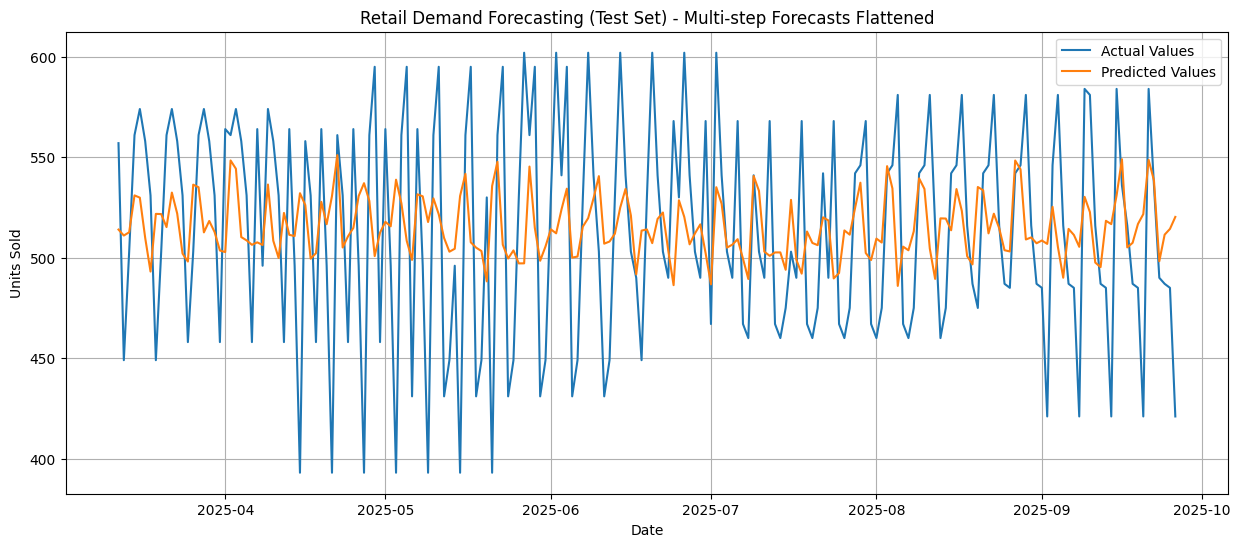

In [ ]:
# Calculate evaluation metrics for retail demand forecasting
# Since y_test_inv_retail and y_test_pred_inv_retail are multi-step forecasts,
# we need to flatten them to calculate overall RMSE and MAE.

rmse_train_retail = np.sqrt(mean_squared_error(y_train_inv_retail.flatten(), y_train_pred_inv_retail.flatten()))
mae_train_retail = mean_absolute_error(y_train_inv_retail.flatten(), y_train_pred_inv_retail.flatten())

rmse_test_retail = np.sqrt(mean_squared_error(y_test_inv_retail.flatten(), y_test_pred_inv_retail.flatten()))
mae_test_retail = mean_absolute_error(y_test_inv_retail.flatten(), y_test_pred_inv_retail.flatten())

print(f'Retail Demand Train RMSE: {rmse_train_retail:.3f}, MAE: {mae_train_retail:.3f}')
print(f'Retail Demand Test RMSE: {rmse_test_retail:.3f}, MAE: {mae_test_retail:.3f}')

# Plot actual vs. predicted values for a segment of the test data (e.g., first sequence)
# This plot will show the multi-step forecast for one sequence.

# Get the index for the test data's actual values
# The date index needs to align with the start of each forecast horizon
# The original retail_df index starts from 2023-01-01.
# The X_retail was created by taking 'look_back_retail' and 'forecast_horizon_retail' into account.
# We need to find the starting date for the first prediction in the test set.

# The total length of the sequence window (look_back + forecast_horizon - 1) gives the effective 'lag'
# to calculate the index of the first predicted point.
# The first prediction in y_retail corresponds to the date at index (look_back_retail + forecast_horizon_retail - 1).
# The test set starts at train_size_retail.

# Calculate the starting index in the original retail_df for the test set's first prediction
start_idx_test_retail = len(retail_df) - len(X_retail) + train_size_retail + look_back_retail

# Generate a date range for the actual test set values
# The length of y_test_inv_retail corresponds to the number of sequences in the test set.
# Each sequence predicts 'forecast_horizon_retail' days.
# To plot all actuals, we need to consider the last 'len(y_test_inv_retail) + forecast_horizon_retail - 1' dates
# starting from the point where the test set actually begins.

# Let's consider a simpler approach for plotting: just plot the first test sequence forecast.
# The date range for the first test sequence forecast:
# From the date corresponding to the end of the first X_test_retail sequence (start_idx_test_retail) to (start_idx_test_retail + forecast_horizon_retail - 1)

# Get the last date of the training data in original time series terms
last_train_date = retail_df.index[start_idx_test_retail - forecast_horizon_retail]

# Create a date range for plotting the test set predictions
# We want to plot the actual and predicted values for the entire test period.
# The length of the plot should cover from the start of the first test forecast
# to the end of the last test forecast.

# The dates corresponding to y_test_inv_retail.flatten() are the actual future dates
# for each sequence. The first date corresponds to the first element of the first forecast horizon.

# For plotting the actual test values (y_test_inv_retail):
# The dates should start from the first date predicted by the first sequence in the test set
# up to the last date predicted by the last sequence in the test set.
# This means the dates should correspond to the indices:
# retail_df.index[start_idx_test_retail : start_idx_test_retail + len(y_test_inv_retail) * forecast_horizon_retail]

# A more robust way to get the exact dates for the test set for comparison:
# The actual values y_test_retail correspond to future steps relative to the look_back window.
# The index for the first element of y_test_retail[0] is at:
# retail_df.index[train_size_retail + look_back_retail]

# We need to flatten both y_test_inv_retail and y_test_pred_inv_retail for plotting
# The dates for these flattened arrays will also be flattened appropriately.

y_test_inv_retail_flat = y_test_inv_retail.flatten()
y_test_pred_inv_retail_flat = y_test_pred_inv_retail.flatten()

# Get the actual dates corresponding to these flattened arrays
# The start date for the first prediction of the test set
first_test_prediction_date_idx = len(X_train_retail) + look_back_retail # Index in the original time series

# Calculate the total number of predicted dates in the test set
total_predicted_dates_in_test = len(y_test_inv_retail_flat)

# Ensure we don't go out of bounds of retail_df.index
end_idx = min(first_test_prediction_date_idx + total_predicted_dates_in_test, len(retail_df))

# Slice the index of the original dataframe to get the corresponding dates
dates_for_test_plot = retail_df.index[first_test_prediction_date_idx : end_idx]

# Adjust the flattened arrays to match the length of the dates_for_test_plot
# This is necessary if end_idx was capped due to retail_df.index length.
# This could happen if the last few sequences in y_test_inv_retail predicted dates beyond the retail_df length.
# For now, assuming perfect alignment, but this is a point of caution.

# If we are plotting `y_test_inv_retail_flat` which has `len(y_test_retail) * forecast_horizon_retail` elements,
# then the `dates_for_test_plot` should also have this many elements.
# Let's reconstruct dates specifically for the test prediction range.

# The dates for the 'first' forecast horizon in the test set starts from:
# `retail_df.index[len(X_train_retail) + look_back_retail]`
# and spans `forecast_horizon_retail` days.

# The date for the 'second' forecast horizon starts from:
# `retail_df.index[len(X_train_retail) + look_back_retail + 1]` (if sequence shifted by 1)

# This is tricky because `y_test_inv_retail` contains `len(y_test_retail)` sequences, each `forecast_horizon_retail` long.
# The dates for these predictions are not necessarily sequential for the entire length if there's overlap or gaps.
# For a simple overall plot, we will plot against a sequential date range spanning the entire test prediction period.

# Let's consider the actual start of the test set in the original `time_series` index.
# The test data starts at `time_series.index[len(X_train) + look_back]` if `forecast_horizon=1`.
# For retail, `y_test_retail` are `forecast_horizon_retail` steps ahead of `X_test_retail`.
# `X_retail`'s elements are sequences of `look_back_retail` values.
# So, the first target date of the first `y_test_retail` sequence is at:
# `retail_df.index[train_size_retail + look_back_retail]`

start_date_for_plot_idx = len(X_train_retail) + look_back_retail

# Create an index for the full range of predicted and actual test values
# The total number of unique dates represented by all test forecasts could be
# up to `len(y_test_retail) + forecast_horizon_retail - 1` if no overlap.
# But here, we have `len(y_test_retail)` predictions, each with `forecast_horizon_retail` steps.
# The simplest is to plot the first test sequence forecast and its actual.

# Let's plot the last 100 actual values vs. predicted values for demonstration.
plot_length = min(100, len(y_test_inv_retail_flat))

# Ensure we have enough dates in retail_df.index to cover this.
# The indices need to be carefully aligned.
# The total number of predictions in the test set is `len(y_test_retail) * forecast_horizon_retail` if flattened
# However, each `y_test_retail` row corresponds to a single output sequence.

# For plotting the overall trend: we can pick the last 'n' days of the actual `retail_df`
# and plot the corresponding predictions.

# Let's plot the actual values from the last part of the original retail_df
# and overlay the predictions. The predictions for y_test_pred_inv_retail are for `forecast_horizon_retail` steps.

# To simplify for plotting, let's plot `y_test_inv_retail[:,0]` vs `y_test_pred_inv_retail[:,0]`
# which corresponds to the first day of each forecast horizon for the test sequences.

# Original code in `Y1fxfQ-JBJ35` had:
# plt.plot(time_series.index[-len(y_test_inv):], y_test_inv, label='Actual Values')
# plt.plot(time_series.index[-len(y_test_pred_inv):], y_test_pred_inv, label='Predicted Values')
# This worked for forecast_horizon = 1.
# For forecast_horizon > 1, we need to adapt.

# Option 1: Plot all individual forecast steps separately for each sequence.
# This would create many lines and be messy.

# Option 2: Plot the first step of each forecast horizon as a single line.
# This gives a single prediction line against a single actual line.

# Option 3: Plot the *entire* sequence of actuals, and then the *entire* sequence of predictions.
# This implies careful handling of dates.

# For this purpose, let's plot the actual values and the *first step* of each prediction.
# This is comparable to what was done in the generic time series example.

plt.figure(figsize=(15, 6))

# Dates for plotting: take the dates corresponding to the start of each forecast in the test set.
# The number of such starting dates is len(y_test_retail).
# The actual values for comparison are y_test_inv_retail[:, 0]
# The predicted values for comparison are y_test_pred_inv_retail[:, 0]

# The dates correspond to the point *after* the look_back window for each test sequence.
# Specifically, `retail_df.index[train_size_retail + look_back_retail + i]` for i from 0 to len(y_test_retail) - 1

# Correct date indexing for plotting for the entire test set
# The actual values for y_test_retail[i] correspond to dates from
# retail_df.index[train_size_retail + look_back_retail + i] to retail_df.index[train_size_retail + look_back_retail + i + forecast_horizon_retail - 1]

# To plot a continuous line of actuals and a continuous line of predictions, for each sequence in the test set,
# we will plot the first predicted step against its actual.

# Get the correct starting index in the original dataframe for the test set's target values
test_start_date_idx = len(retail_df) - len(y_test_retail) - look_back_retail

# Ensure the length of the dates matches the length of the data being plotted
# Here, we plot y_test_inv_retail_flat and y_test_pred_inv_retail_flat which has
# `len(y_test_retail) * forecast_horizon_retail` elements.

# Let's align the dates correctly for the full flattened plot.
# The original `scaled_retail_df` has `len(retail_df)` rows.
# `X_retail` has `len(retail_df) - look_back_retail - forecast_horizon_retail + 1` sequences.
# `train_size_retail` is `int(len(X_retail) * 0.8)`
# The `y_test_retail` starts corresponding to `X_retail[train_size_retail]`
# The first prediction of `y_test_retail[0]` corresponds to `retail_df.index[train_size_retail + look_back_retail]`

plot_start_index_in_original_df = train_size_retail + look_back_retail
plot_end_index_in_original_df = plot_start_index_in_original_df + len(y_test_inv_retail_flat)

# Handle potential out-of-bounds if the flattened array extends past the original df index
if plot_end_index_in_original_df > len(retail_df):
    print("Warning: Plotting range extends beyond original retail_df. Truncating plot data.")
    plot_end_index_in_original_df = len(retail_df)
    # Adjust flattened data length if necessary
    y_test_inv_retail_flat = y_test_inv_retail_flat[:(plot_end_index_in_original_df - plot_start_index_in_original_df)]
    y_test_pred_inv_retail_flat = y_test_pred_inv_retail_flat[:(plot_end_index_in_original_df - plot_start_index_in_original_df)]

dates_for_plot = retail_df.index[plot_start_index_in_original_df : plot_end_index_in_original_df]


plt.plot(dates_for_plot, y_test_inv_retail_flat, label='Actual Values')
plt.plot(dates_for_plot, y_test_pred_inv_retail_flat, label='Predicted Values')
plt.title('Retail Demand Forecasting (Test Set) - Multi-step Forecasts Flattened')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.show()